# Playground: BraTS Pred vs Target Slice Visualization
Visualize sample slices from:
- predictions: `data/nnUNet_results/nnunet/Dataset137_BraTS2021/nnUNetTrainer__nnUNetPlans__2d_tiny16/fold_0/test/Dataset137_BraTS2021/preds`
- targets: `data/nnUNet_raw/Dataset137_BraTS2021/labelsTs`
- inputs: `data/nnUNet_raw/Dataset137_BraTS2021/imagesTs`

In [1]:
from pathlib import Path
import random

import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt

# cfg = "2d_tiny16"
cfg = "2d"
PRED_DIR = Path(f'data/nnUNet_results/nnunet/Dataset137_BraTS2021/nnUNetTrainer__nnUNetPlans__{cfg}/fold_0/test/Dataset137_BraTS2021/preds')
RAW_DIR = Path('data/nnUNet_raw/Dataset137_BraTS2021')
IMAGES_TS = RAW_DIR / 'imagesTs'
LABELS_TS = RAW_DIR / 'labelsTs'

pred_files = sorted([p for p in PRED_DIR.glob('*.nii.gz') if p.is_file()])
case_ids = [p.name.replace('.nii.gz', '') for p in pred_files]

print('pred cases:', len(case_ids))
print('first 10:', case_ids[:10])

pred cases: 38
first 10: ['BraTS2021_00019', 'BraTS2021_00032', 'BraTS2021_00077', 'BraTS2021_00084', 'BraTS2021_00095', 'BraTS2021_00099', 'BraTS2021_00124', 'BraTS2021_00131', 'BraTS2021_00134', 'BraTS2021_00156']


In [2]:
def load_nii(path):
    return np.asarray(nib.load(str(path)).get_fdata())


def get_input_path(case_id, channel=1):
    return IMAGES_TS / f"{case_id}_{channel:04d}.nii.gz"


def get_pred_path(case_id):
    return PRED_DIR / f"{case_id}.nii.gz"


def get_label_path(case_id):
    return LABELS_TS / f"{case_id}.nii.gz"


def choose_slice(pred, target):
    # choose slice with largest foreground in target, fallback to prediction
    if pred.ndim != 3:
        return None
    t_fg = (target > 0).sum(axis=(1, 2))
    if np.any(t_fg):
        return int(np.argmax(t_fg))
    p_fg = (pred > 0).sum(axis=(1, 2))
    if np.any(p_fg):
        return int(np.argmax(p_fg))
    return pred.shape[0] // 2


def normalize(img2d):
    x = np.asarray(img2d, dtype=np.float32)
    lo = np.percentile(x, 1)
    hi = np.percentile(x, 99)
    if hi <= lo:
        lo, hi = float(np.min(x)), float(np.max(x))
    if hi <= lo:
        return np.zeros_like(x, dtype=np.float32)
    y = (x - lo) / (hi - lo)
    return np.clip(y, 0, 1)


def draw_case(case_id, channel=1, z=None):
    pred = load_nii(get_pred_path(case_id)).astype(np.int32)
    target = load_nii(get_label_path(case_id)).astype(np.int32)
    inp = load_nii(get_input_path(case_id, channel=channel)).astype(np.float32)

    if pred.shape != target.shape:
        raise ValueError(f'shape mismatch pred {pred.shape} vs target {target.shape}')

    if z is None and pred.ndim == 3:
        z = choose_slice(pred, target)

    if pred.ndim == 3:
        pred2d = pred[z]
        target2d = target[z]
        inp2d = inp[z] if inp.ndim == 3 else inp
        title_suffix = f' (z={z})'
    else:
        pred2d = pred
        target2d = target
        inp2d = inp if inp.ndim == 2 else inp[inp.shape[0] // 2]
        title_suffix = ''

    base = normalize(inp2d)

    fig, ax = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle(f'{case_id}{title_suffix}', fontsize=12)

    ax[0].imshow(base, cmap='gray')
    ax[0].set_title(f'Input channel {channel}')
    ax[0].axis('off')

    ax[1].imshow(base, cmap='gray')
    ax[1].imshow(np.ma.masked_where(pred2d == 0, pred2d), cmap='jet', alpha=0.45, vmin=1, vmax=3)
    ax[1].set_title('Prediction overlay')
    ax[1].axis('off')

    ax[2].imshow(base, cmap='gray')
    ax[2].imshow(np.ma.masked_where(target2d == 0, target2d), cmap='jet', alpha=0.45, vmin=1, vmax=3)
    ax[2].set_title('Target overlay')
    ax[2].axis('off')

    plt.tight_layout()
    plt.show()

    print('pred labels:', np.unique(pred2d))
    print('target labels:', np.unique(target2d))

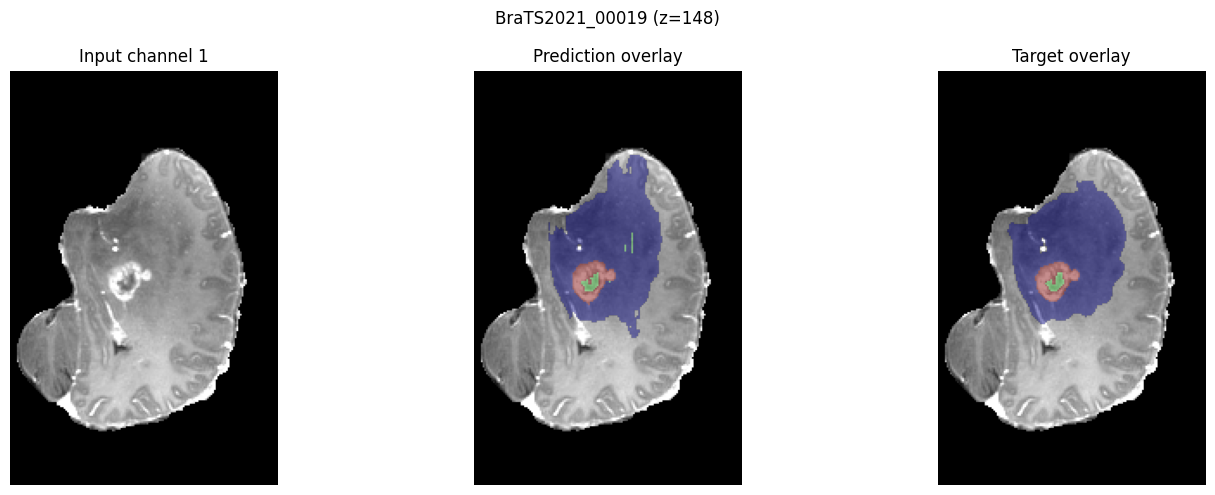

pred labels: [0 1 2 3]
target labels: [0 1 2 3]


In [3]:
# Single case quick check
case_id = case_ids[0]
draw_case(case_id, channel=1)

sample_ids: ['BraTS2021_00263', 'BraTS2021_00032', 'BraTS2021_00191', 'BraTS2021_00296', 'BraTS2021_00504', 'BraTS2021_00230', 'BraTS2021_00269', 'BraTS2021_00478']


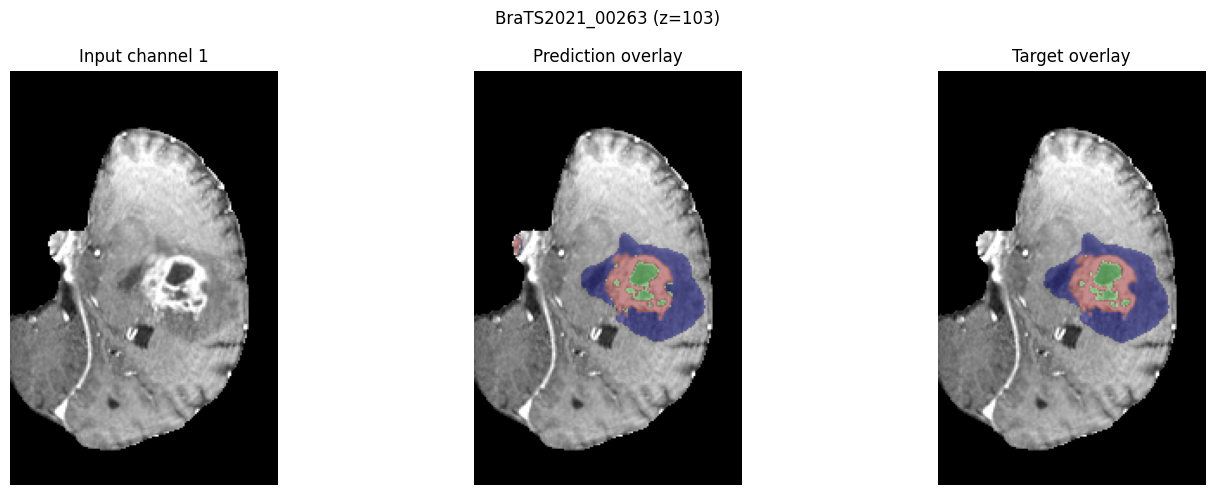

pred labels: [0 1 2 3]
target labels: [0 1 2 3]


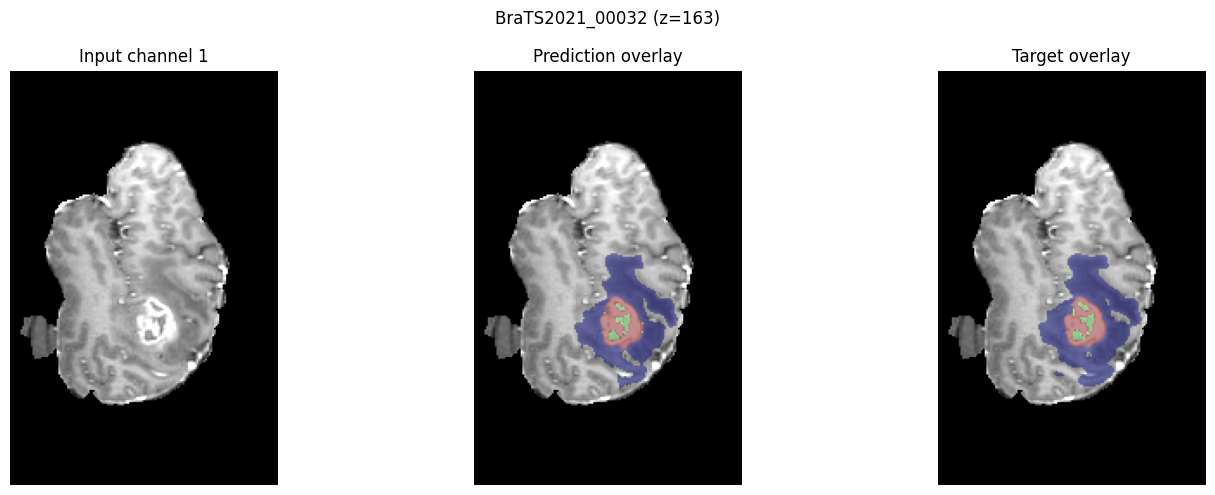

pred labels: [0 1 2 3]
target labels: [0 1 2 3]


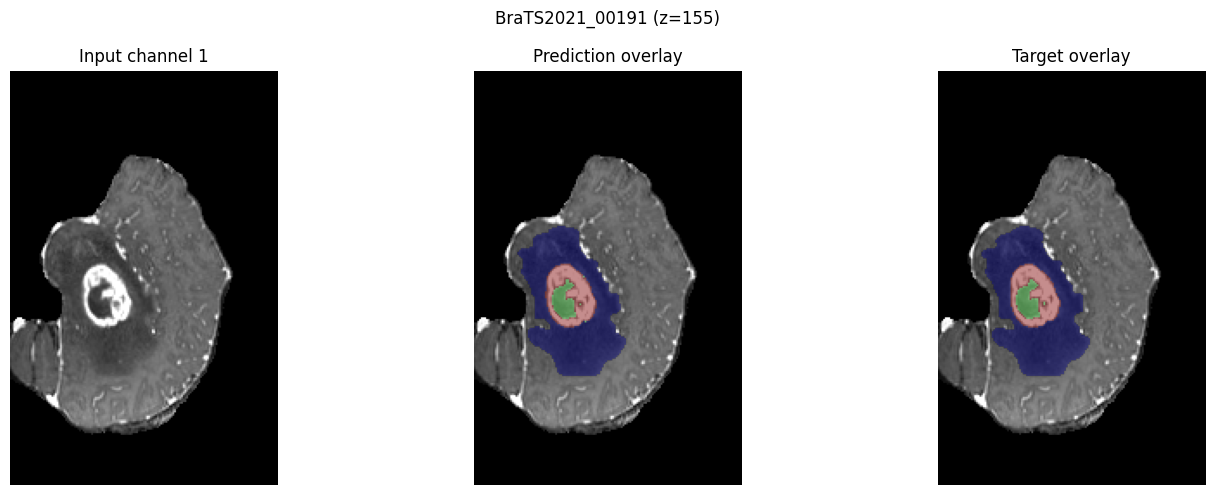

pred labels: [0 1 2 3]
target labels: [0 1 2 3]


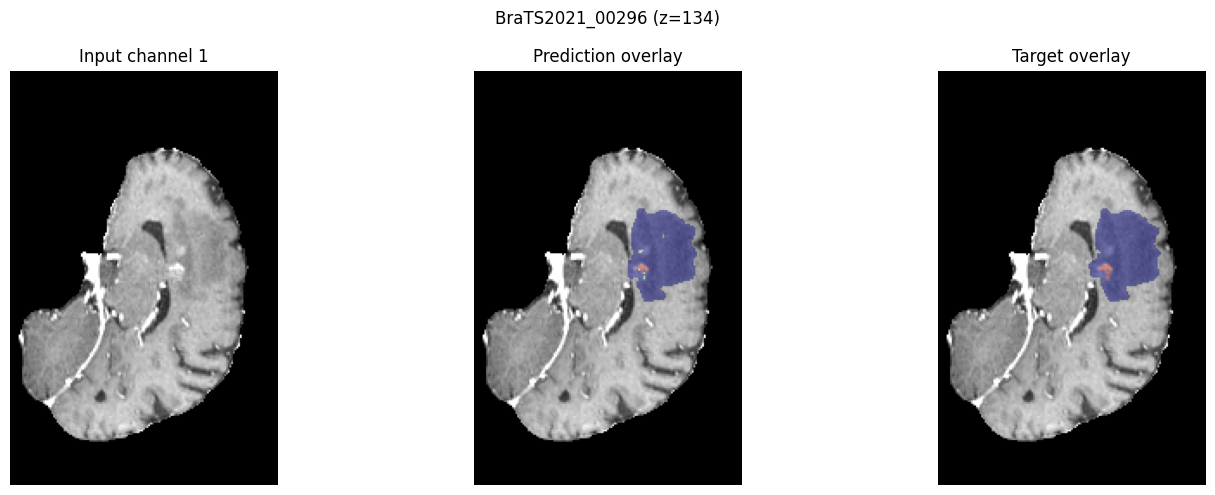

pred labels: [0 1 2 3]
target labels: [0 1 3]


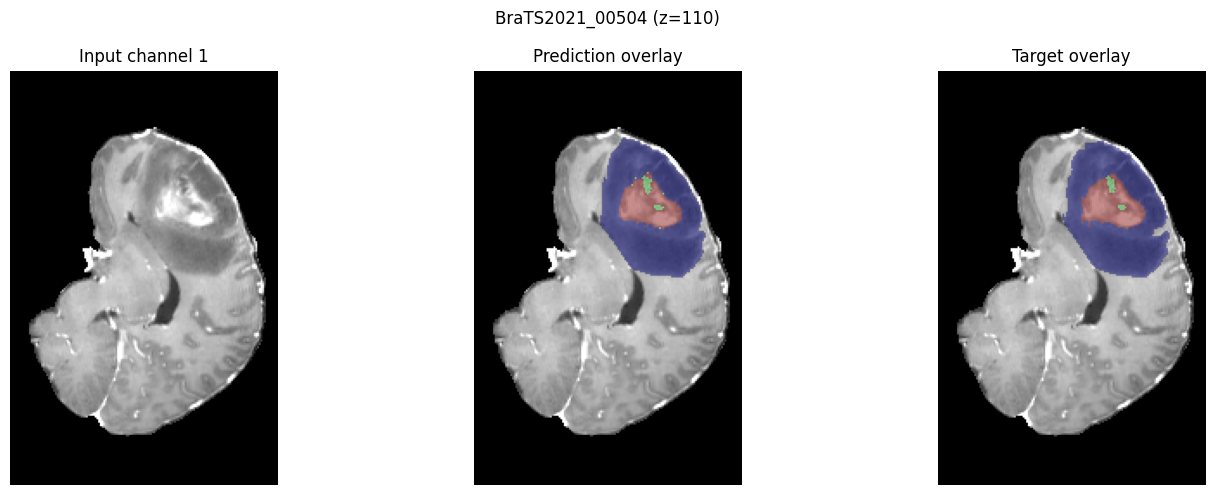

pred labels: [0 1 2 3]
target labels: [0 1 2 3]


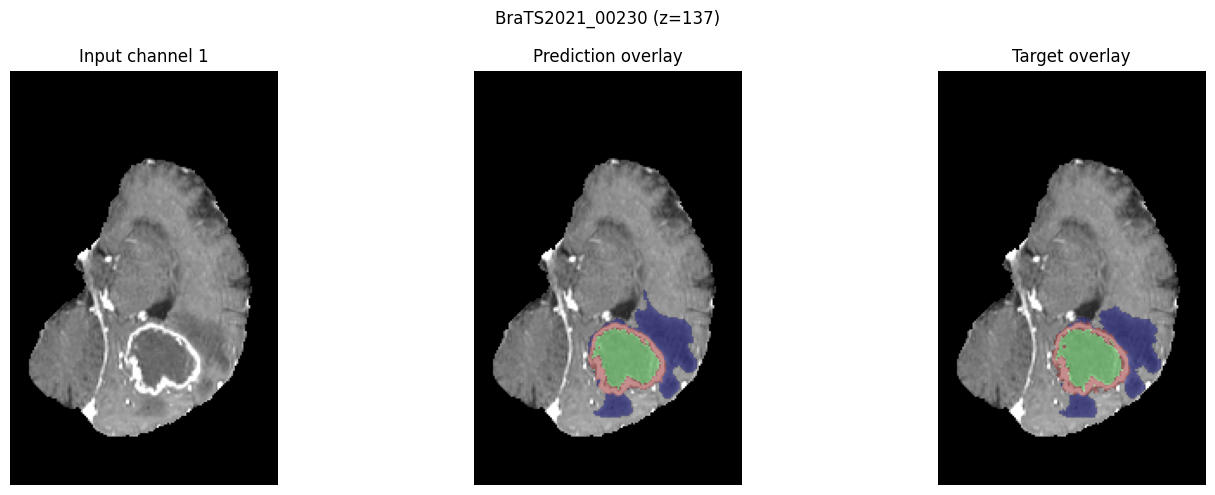

pred labels: [0 1 2 3]
target labels: [0 1 2 3]


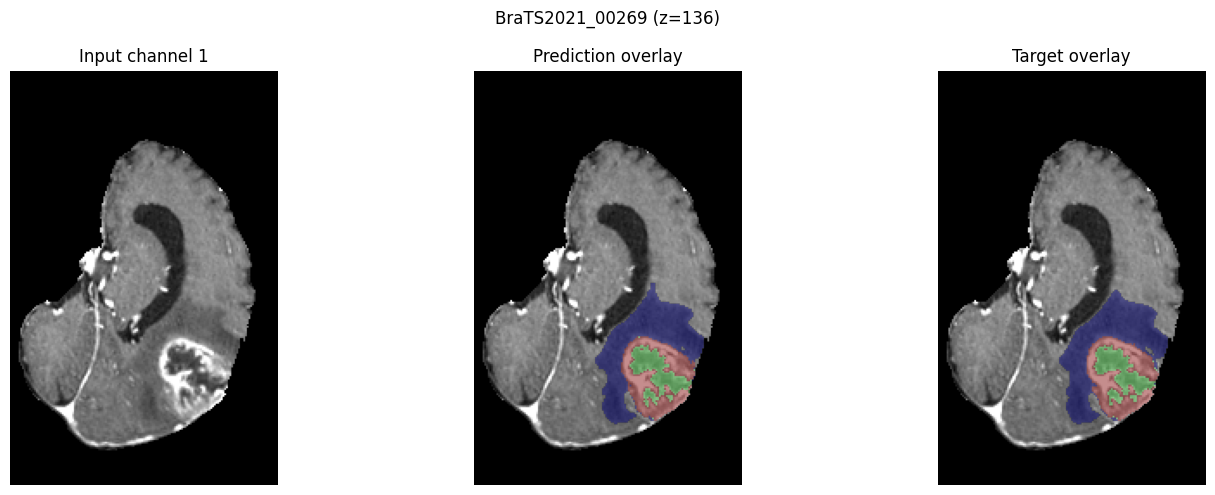

pred labels: [0 1 2 3]
target labels: [0 1 2 3]


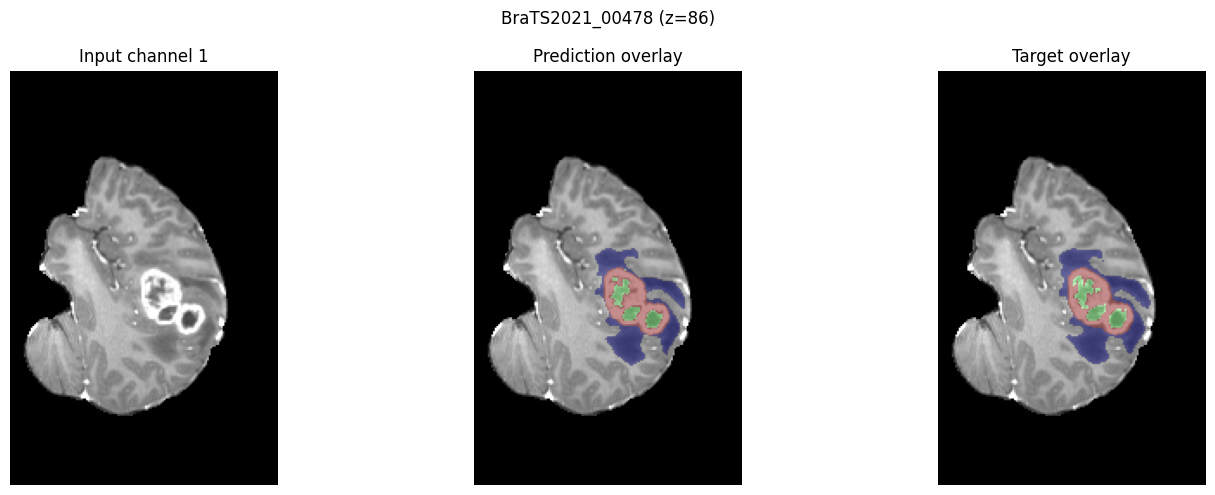

pred labels: [0 1 2 3]
target labels: [0 1 2 3]


In [4]:
# Visualize multiple random cases
num_cases = 8
# seed = 42
channel = 1  # 0:T1, 1:T1ce, 2:T2, 3:Flair

rng = random.Random() #seed)
sample_ids = case_ids if num_cases >= len(case_ids) else rng.sample(case_ids, num_cases)
print('sample_ids:', sample_ids)

for cid in sample_ids:
    draw_case(cid, channel=channel)

In [5]:
# Optional: inspect one problematic case explicitly
# draw_case('BraTS2021_00019', channel=1, z=None)

In [6]:
import pandas as pd
from scipy.ndimage import binary_erosion, distance_transform_edt

REGIONS = {
    'WT': [1, 2, 3],
    'TC': [2, 3],
    'ET': [3],
}

def dice_binary(pred_bin, gt_bin):
    pred_bin = pred_bin.astype(bool)
    gt_bin = gt_bin.astype(bool)
    inter = np.logical_and(pred_bin, gt_bin).sum()
    denom = pred_bin.sum() + gt_bin.sum()
    if denom == 0:
        return 1.0
    return (2.0 * inter) / float(denom)

def _surface_points(mask):
    if not np.any(mask):
        return mask
    er = binary_erosion(mask, iterations=1, border_value=0)
    return np.logical_and(mask, np.logical_not(er))

def _surface_distances(a, b):
    # Distances from surface(a) to nearest voxel in surface(b).
    sa = _surface_points(a)
    sb = _surface_points(b)
    if not np.any(sa) and not np.any(sb):
        return np.array([0.0], dtype=np.float64)
    if not np.any(sa) or not np.any(sb):
        return np.array([np.inf], dtype=np.float64)
    dt = distance_transform_edt(~sb)
    return dt[sa].astype(np.float64)

def hd95_binary(pred_bin, gt_bin):
    d1 = _surface_distances(pred_bin, gt_bin)
    d2 = _surface_distances(gt_bin, pred_bin)
    d = np.concatenate([d1, d2])
    if not np.all(np.isfinite(d)):
        return np.nan
    return float(np.percentile(d, 95))

def masd_binary(pred_bin, gt_bin):
    d1 = _surface_distances(pred_bin, gt_bin)
    d2 = _surface_distances(gt_bin, pred_bin)
    d = np.concatenate([d1, d2])
    if not np.all(np.isfinite(d)):
        return np.nan
    return float(np.mean(d))

def region_metrics(pred_arr, gt_arr, labels):
    p = np.isin(pred_arr, labels)
    g = np.isin(gt_arr, labels)
    return {
        'dice': dice_binary(p, g),
        'hd95': hd95_binary(p, g),
        'masd': masd_binary(p, g),
    }


In [7]:
from tqdm import tqdm

# Compute volume-wise Dice + HD95 for all predicted cases
# and save both image-wise + aggregate CSV files.
ids = case_ids

rows = []
for cid in tqdm(ids):
    pred = load_nii(get_pred_path(cid)).astype(np.int32)
    gt = load_nii(get_label_path(cid)).astype(np.int32)

    for region_name, labels in REGIONS.items():
        p_vol = np.isin(pred, labels)
        g_vol = np.isin(gt, labels)

        rows.append({
            'case_id': cid,
            'region': region_name,
            'dice_vol': dice_binary(p_vol, g_vol) * 100.0,
            'hd95_vol': hd95_binary(p_vol, g_vol),
        })

# Long-format per-region table
df_metrics = pd.DataFrame(rows)
display(df_metrics.head(12))

summary_metrics = (
    df_metrics.groupby('region')[['dice_vol', 'hd95_vol']]
      .mean(numeric_only=True)
      .round(3)
)
print(f'Mean volume-wise metrics over all predicted cases ({len(ids)} cases):')
display(summary_metrics)

# image-wise CSV: one row per case (WT/TC/ET + overall)
piv_d = df_metrics.pivot(index='case_id', columns='region', values='dice_vol')
piv_h = df_metrics.pivot(index='case_id', columns='region', values='hd95_vol')
for r in ['WT', 'TC', 'ET']:
    if r not in piv_d.columns:
        piv_d[r] = np.nan
    if r not in piv_h.columns:
        piv_h[r] = np.nan
piv_d = piv_d[['WT', 'TC', 'ET']]
piv_h = piv_h[['WT', 'TC', 'ET']]

imagewise_out = pd.DataFrame(index=piv_d.index)
imagewise_out['dice_wt'] = piv_d['WT']
imagewise_out['dice_tc'] = piv_d['TC']
imagewise_out['dice_et'] = piv_d['ET']
imagewise_out['dice'] = piv_d[['WT', 'TC', 'ET']].mean(axis=1)
imagewise_out['hd95_wt'] = piv_h['WT']
imagewise_out['hd95_tc'] = piv_h['TC']
imagewise_out['hd95_et'] = piv_h['ET']
imagewise_out['hd95'] = piv_h[['WT', 'TC', 'ET']].mean(axis=1)
imagewise_out = imagewise_out.reset_index().rename(columns={'case_id': 'image_id'})

# aggregate results.csv style output
results_out = pd.DataFrame([
    {
        'test_dataset_name': 'Dataset137_BraTS2021',
        'dice': float(np.nanmean(imagewise_out['dice'].values)),
        'dice_std': float(np.nanstd(imagewise_out['dice'].values)),
        'hd95': float(np.nanmean(imagewise_out['hd95'].values)),
        'hd95_std': float(np.nanstd(imagewise_out['hd95'].values)),
    }
])

out_dir = PRED_DIR.parent.parent  # .../fold_0/test
imagewise_csv = out_dir / 'image_wise_results_Dataset137_BraTS2021.csv'
results_csv = out_dir / 'results.csv'

imagewise_out.to_csv(imagewise_csv, index=False, float_format='%.2f')
results_out.to_csv(results_csv, index=False, float_format='%.2f')

print('Saved:', imagewise_csv)
print('Saved:', results_csv)
print(results_out.to_string(index=False))



100%|██████████| 38/38 [02:38<00:00,  4.18s/it]


,case_id,region,dice_vol,hd95_vol
0,BraTS2021_00019,WT,90.666640,8.485281
1,BraTS2021_00019,TC,91.861265,5.000000
2,BraTS2021_00019,ET,91.561121,1.000000
3,BraTS2021_00032,WT,95.853896,1.414214
4,BraTS2021_00032,TC,94.696818,1.414214
5,BraTS2021_00032,ET,91.793574,1.732051
6,BraTS2021_00077,WT,96.142953,2.236068
7,BraTS2021_00077,TC,97.975815,1.000000
8,BraTS2021_00077,ET,96.003070,1.000000
9,BraTS2021_00084,WT,92.666778,3.162278


Mean volume-wise metrics over all predicted cases (38 cases):


,dice_vol,hd95_vol
region,,
ET,87.383,2.307
TC,91.514,3.900
WT,94.687,2.468


Saved: data/nnUNet_results/nnunet/Dataset137_BraTS2021/nnUNetTrainer__nnUNetPlans__2d/fold_0/test/image_wise_results_Dataset137_BraTS2021.csv
Saved: data/nnUNet_results/nnunet/Dataset137_BraTS2021/nnUNetTrainer__nnUNetPlans__2d/fold_0/test/results.csv
   test_dataset_name      dice  dice_std     hd95  hd95_std
Dataset137_BraTS2021 91.194625 11.172085 2.891683  3.329839


In [63]:
# Overall volume-wise Dice and HD95 over all regions (WT/TC/ET)
# 1) per-case mean over regions (already in imagewise_out as dice and hd95)
# 2) overall mean/std across cases

if 'imagewise_out' not in globals():
    raise RuntimeError("Run the volume-wise Dice+HD95 computation cell first.")

overall_dice_mean = float(np.nanmean(imagewise_out['dice'].values))
overall_dice_std = float(np.nanstd(imagewise_out['dice'].values))
overall_hd95_mean = float(np.nanmean(imagewise_out['hd95'].values))
overall_hd95_std = float(np.nanstd(imagewise_out['hd95'].values))

print(f"Overall Dice (all regions): {overall_dice_mean:.2f} ± {overall_dice_std:.2f}")
print(f"Overall HD95 (all regions): {overall_hd95_mean:.2f} ± {overall_hd95_std:.2f}")
display(imagewise_out[['image_id', 'dice', 'hd95']].head())
print('Num cases:', len(imagewise_out))



Overall Dice (all regions): 89.47 ± 11.30
Overall HD95 (all regions): 4.15 ± 5.27


,image_id,dice,hd95
0,BraTS2021_00019,91.103665,3.825490
1,BraTS2021_00032,94.575578,1.333333
2,BraTS2021_00077,96.177955,3.116156
3,BraTS2021_00084,91.028130,3.021498
4,BraTS2021_00095,95.163427,1.138071


Num cases: 126
